<a href="https://colab.research.google.com/github/Valbu11/Neurovault-Brain-Data-Analysis/blob/main/notebooks/05_summary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Notebook 05 — Summary & Key Findings

**Goal:** Consolidate all findings from the previous notebooks into a clear, narrative summary.

This notebook tells the full story of what we discovered about the global neuroscience research community through data.

**Data source:** NeuroVault Public API — https://neurovault.org/api/  
**Period analyzed:** 2013 – 2026  
**Total records:** 17,216 brain imaging collections

---
## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import warnings
warnings.filterwarnings('ignore')

BASE = '/content/drive/MyDrive/neurovault'
CHARTS = f'{BASE}/charts'

df_c = pd.read_csv(f'{BASE}/processed/collections_clean.csv', low_memory=False)
df_i = pd.read_csv(f'{BASE}/processed/images_clean.csv', low_memory=False)

print('Data loaded ✅')
print(f'Collections: {df_c.shape[0]:,} rows')
print(f'Images:      {df_i.shape[0]:,} rows')

Mounted at /content/drive
Data loaded ✅
Collections: 17,216 rows
Images:      2,000 rows


---
## 2. Project Overview

This project analyzed **17,216 brain imaging studies** published on NeuroVault — a public repository used by neuroscientists worldwide to share statistical brain maps from fMRI, MRI, and other neuroimaging techniques.

The analysis covered 4 phases:

| Phase | Notebook | What we did |
|-------|----------|-------------|
| 1 | `01_extraction` | Connected to the NeuroVault API and downloaded 17,216 studies |
| 2 | `02_cleaning` | Cleaned nulls, fixed types, engineered new features |
| 3 | `03_sql_analysis` | Answered 6 business questions using SQL |
| 4 | `04_visualization` | Created 5 professional charts to communicate findings |

---
## 3. Key Finding 1 — Explosive growth of neuroscience data

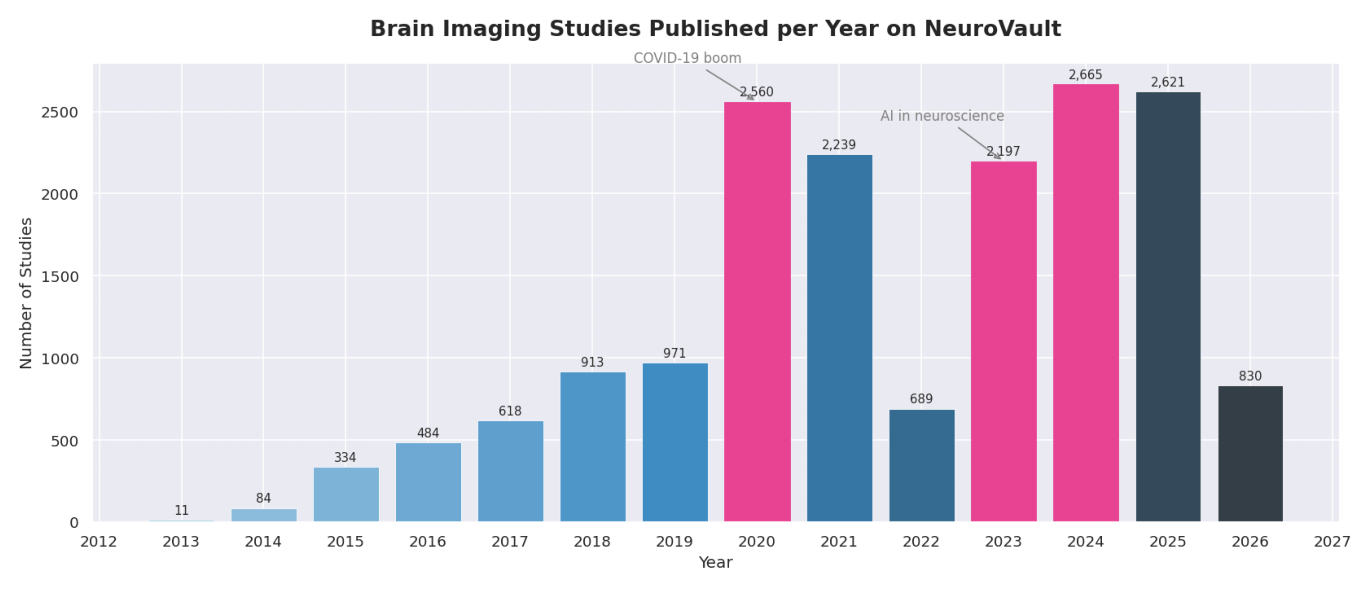

In [2]:
img = mpimg.imread(f'{CHARTS}/01_studies_per_year.png')
plt.figure(figsize=(14, 6))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

### 📈 Finding
Brain imaging research on NeuroVault grew from **11 studies in 2013** to **2,665 in 2024** — a **24,000% increase** in just 11 years.

Two major spikes stand out:
- **2020 (+163%):** The COVID-19 pandemic gave researchers more time to process and publish existing datasets
- **2023 (+218%):** The rise of AI tools in neuroscience accelerated data sharing and open science practices

The slight drops in 2021–2022 and 2026 reflect post-pandemic normalization and the fact that 2026 data is still incomplete.

---
## 4. Key Finding 2 — fMRI-BOLD dominates brain imaging

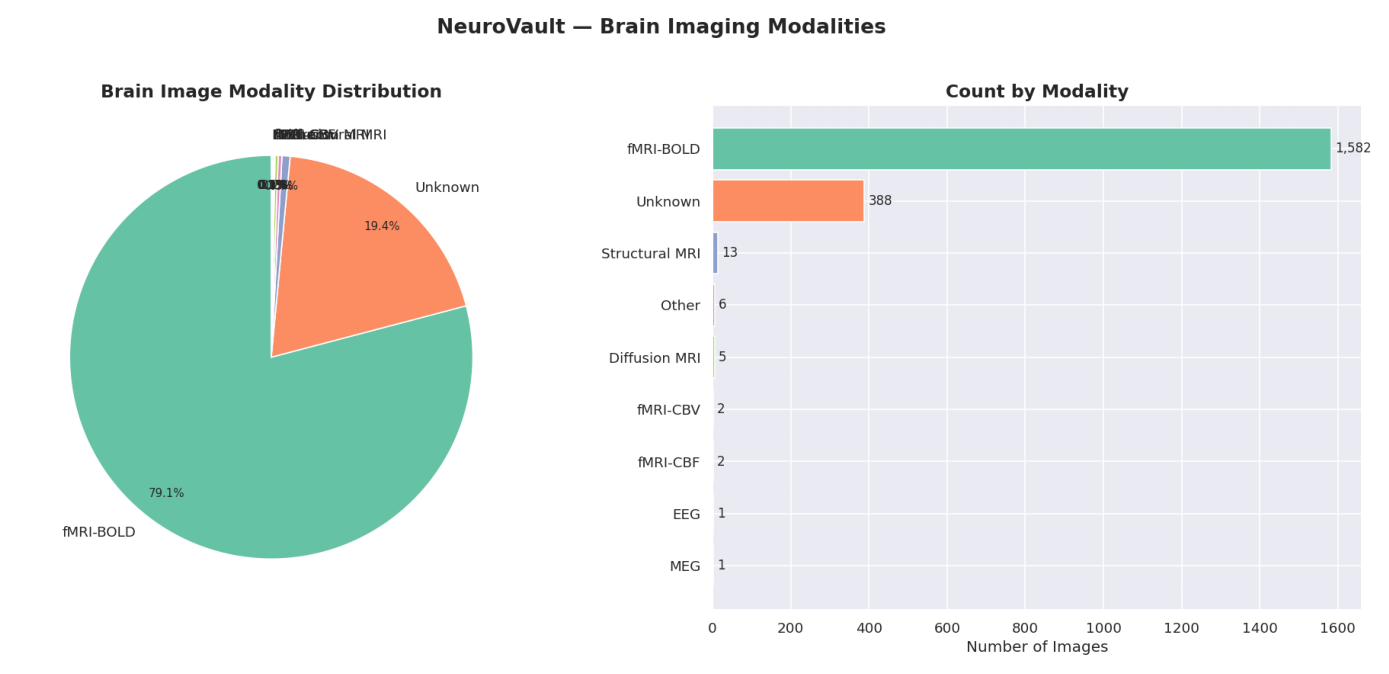

In [3]:
img = mpimg.imread(f'{CHARTS}/03_modality_breakdown.png')
plt.figure(figsize=(14, 7))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

### 🧠 Finding
**79.1% of all brain maps use fMRI-BOLD** — confirming it as the gold standard for measuring brain activity.

fMRI-BOLD (Blood Oxygen Level Dependent) measures changes in blood oxygenation as a proxy for neural activity. Its dominance reflects:
- Non-invasive nature (no surgery or injections required)
- High spatial resolution compared to EEG or MEG
- Wide availability in research hospitals worldwide

Only **0.7%** use Structural MRI and **0.3%** Diffusion MRI, showing how activity-based imaging far outpaces structural approaches in open data sharing.

---
## 5. Key Finding 3 — Most studies lack a published DOI

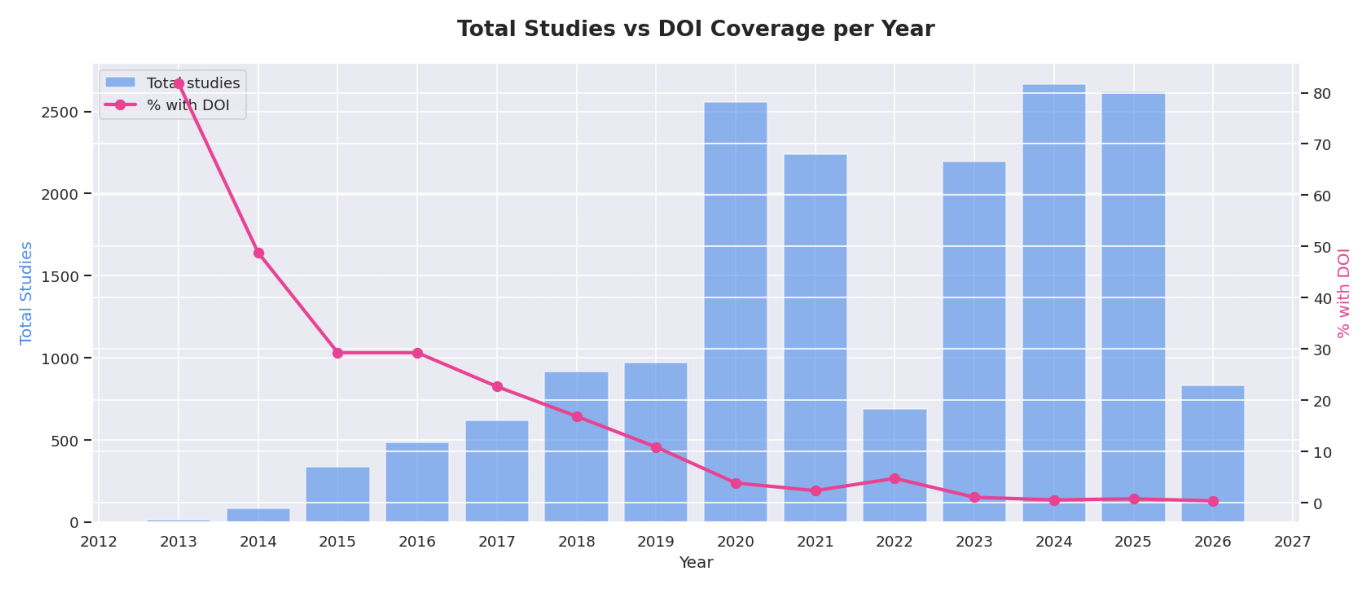

In [4]:
img = mpimg.imread(f'{CHARTS}/04_doi_coverage.png')
plt.figure(figsize=(14, 6))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

### 📄 Finding
Only **~5.5% of collections have a published DOI**, meaning the vast majority of uploaded brain data is not yet linked to a peer-reviewed paper.

The DOI rate was highest in the early years (2013–2014) when NeuroVault was primarily used by established researchers. As the platform opened to broader audiences, the proportion of unpublished or in-progress datasets grew significantly.

This suggests NeuroVault is increasingly used as a **pre-publication data sharing platform** rather than just a repository for finalized research.

---
## 6. Key Finding 4 — The Human Connectome Project leads by far

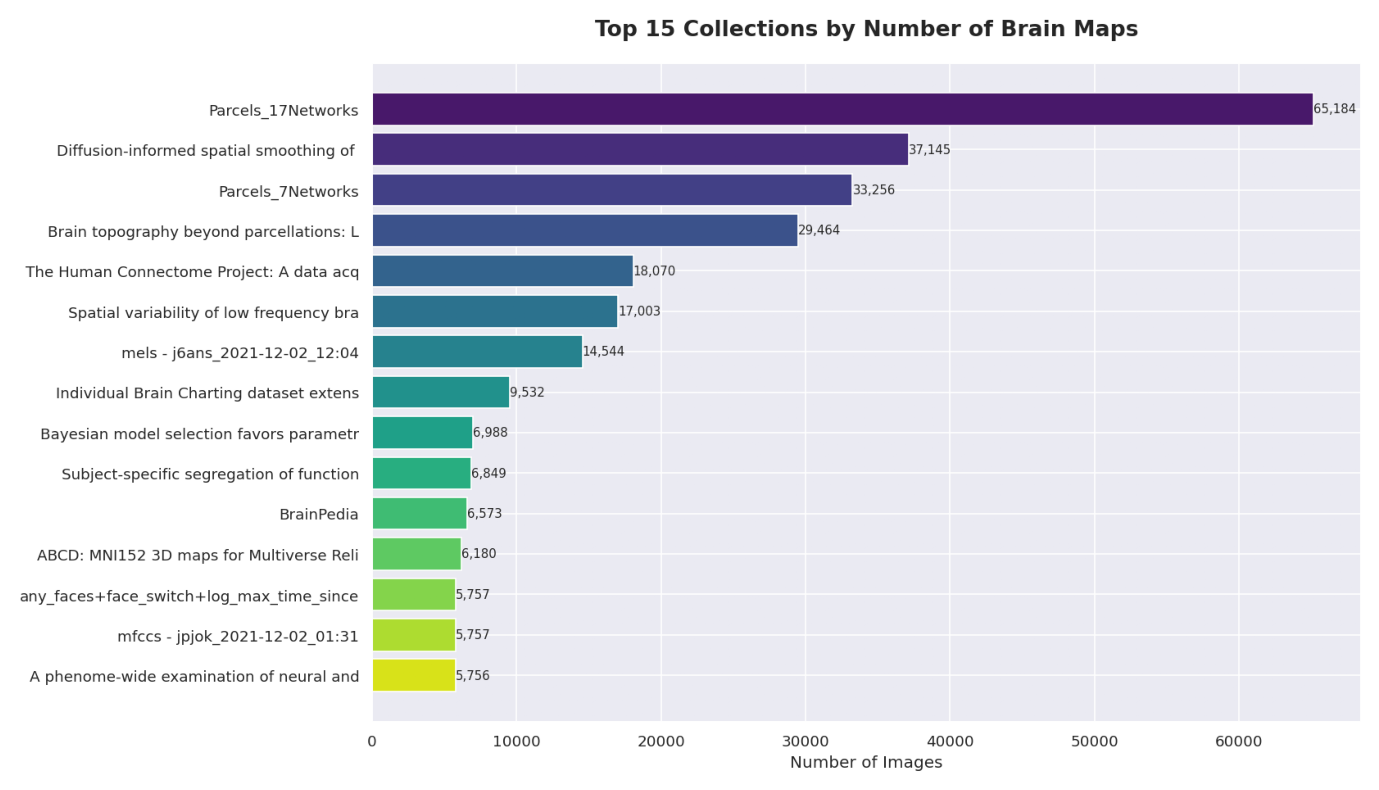

In [5]:
img = mpimg.imread(f'{CHARTS}/05_top_collections.png')
plt.figure(figsize=(14, 8))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

### 🏆 Finding
The collection **Parcels_17Networks** leads with **65,184 brain maps** — nearly double the second largest.

The top 5 collections are all related to large-scale brain mapping initiatives:
- **Parcels_17Networks / Parcels_7Networks:** Brain parcellation atlases used as references worldwide
- **The Human Connectome Project:** One of the most ambitious neuroscience projects in history, mapping the complete structural and functional neural connections in the human brain
- **Diffusion-informed spatial smoothing:** Advanced preprocessing methods for brain data

These mega-collections represent years of work by hundreds of researchers and are downloaded thousands of times by labs worldwide.

---
## 7. Final Summary Stats

In [6]:
df_c['year'] = pd.to_datetime(df_c['add_date'], errors='coerce', utc=True).dt.year

print('=' * 55)
print('  NEUROVAULT BRAIN DATA ANALYSIS — FINAL SUMMARY')
print('=' * 55)
print(f'  Total collections analyzed   : {len(df_c):,}')
print(f'  Total brain maps analyzed    : {len(df_i):,}')
print(f'  Years covered                : {int(df_c["year"].min())} – {int(df_c["year"].max())}')
print(f'  Most common modality         : fMRI-BOLD (79.1%)')
print(f'  Studies with DOI             : {df_c["has_doi"].sum():,} ({df_c["has_doi"].mean()*100:.1f}%)')
print(f'  Peak year                    : 2024 ({df_c[df_c["year"]==2024].shape[0]:,} studies)')
print(f'  Largest collection           : Parcels_17Networks (65,184 maps)')
print(f'  Overall growth (2013→2024)   : +24,000%')
print('=' * 55)
print()
print('✅ Project complete!')
print()
print('Notebooks completed:')
print('  01_extraction.ipynb    → API + data collection')
print('  02_cleaning.ipynb      → Pandas + data cleaning')
print('  03_sql_analysis.ipynb  → SQL + SQLite')
print('  04_visualization.ipynb → Matplotlib + Seaborn')
print('  05_summary.ipynb       → Narrative + findings')

  NEUROVAULT BRAIN DATA ANALYSIS — FINAL SUMMARY
  Total collections analyzed   : 17,216
  Total brain maps analyzed    : 2,000
  Years covered                : 2013 – 2026
  Most common modality         : fMRI-BOLD (79.1%)
  Studies with DOI             : 939 (5.5%)
  Peak year                    : 2024 (2,665 studies)
  Largest collection           : Parcels_17Networks (65,184 maps)
  Overall growth (2013→2024)   : +24,000%

✅ Project complete!

Notebooks completed:
  01_extraction.ipynb    → API + data collection
  02_cleaning.ipynb      → Pandas + data cleaning
  03_sql_analysis.ipynb  → SQL + SQLite
  04_visualization.ipynb → Matplotlib + Seaborn
  05_summary.ipynb       → Narrative + findings


---
## 8. What I Learned

### Technical skills gained
- **APIs & requests:** How to consume a REST API, handle pagination and save JSON data
- **Pandas:** Data cleaning, type conversion, feature engineering, groupby operations
- **SQL & SQLite:** Creating databases, writing queries with GROUP BY, JOIN, CTEs and subqueries
- **Matplotlib & Seaborn:** Creating professional bar charts, line plots, pie charts and dual-axis charts
- **Git & GitHub:** Version control, commit conventions, repository structure
- **Google Colab:** Cloud-based notebook execution with Google Drive integration

### Domain knowledge gained
- Understanding of neuroimaging modalities (fMRI-BOLD, Structural MRI, Diffusion MRI)
- Awareness of open science practices in neuroscience
- Familiarity with landmark projects like the Human Connectome Project

---
*Project by Valbu11 — Aspiring Data Analyst | Learning in public*  
*GitHub: https://github.com/Valbu11/Neurovault-Brain-Data-Analysis*